In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!mkdir tpgsr
!mkdir weights

mkdir: cannot create directory ‘tpgsr’: File exists
mkdir: cannot create directory ‘weights’: File exists


In [3]:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import os

# Download TextOCR dataset
print("Downloading TextOCR dataset...")
textocr_path = kagglehub.dataset_download("robikscube/textocr-text-extraction-from-images-dataset")
print("TextOCR Path:", textocr_path)

# List files to be sure of the names
print("\nFiles in dataset:", os.listdir(textocr_path))

# Try to read and display annot.csv
annot_csv_path = os.path.join(textocr_path, "annot.csv")
if os.path.exists(annot_csv_path):
    print("\n--- annot.csv ---")
    annot_df = pd.read_csv(annot_csv_path, nrows=5)
    display(annot_df)
else:
    print(f"{annot_csv_path} not found.")

# Try to read and display image.csv (or similarly named file)
for file in os.listdir(textocr_path):
    if 'img' in file.lower() and file.endswith('.csv'):
        img_csv_path = os.path.join(textocr_path, file)
        print(f"\n--- {file} ---")
        img_df = pd.read_csv(img_csv_path, nrows=5)
        display(img_df)
        break


Using Colab cache for faster access to the 'textocr-text-extraction-from-images-dataset' dataset.
TextOCR Path: /kaggle/input/textocr-text-extraction-from-images-dataset

Files in dataset: ['img.parquet', 'train_val_images', 'annot.csv', 'annot.parquet', 'TextOCR_0.1_train.json', 'img.csv']

--- annot.csv ---


,Unnamed: 0,id,image_id,bbox,utf8_string,points,area
0,0,a4ea732cd3d5948a_1,a4ea732cd3d5948a,"[525.83, 3.4, 197.64, 33.94]",Performance,"[525.83, 3.4, 723.47, 7.29, 722.76, 36.99, 525...",6707.90
1,1,a4ea732cd3d5948a_2,a4ea732cd3d5948a,"[534.67, 64.68, 91.22, 38.19]",Sport,"[535.73, 64.68, 623.41, 67.51, 625.89, 102.87,...",3483.69
2,2,a4ea732cd3d5948a_3,a4ea732cd3d5948a,"[626.95, 63.62, 96.52, 31.82]",Watch,"[626.95, 63.62, 721.7, 63.62, 723.47, 95.44, 6...",3071.27
3,3,a4ea732cd3d5948a_4,a4ea732cd3d5948a,"[577.4, 141.87, 147.13, 43.1]",...period.,"[580.02, 143.61, 724.53, 141.87, 723.66, 184.9...",6341.30
4,4,a4ea732cd3d5948a_5,a4ea732cd3d5948a,"[391.03, 163.9, 60.82, 38.65]",.,"[395.2, 163.9, 451.85, 191.94, 445.59, 202.55,...",2350.69



--- img.csv ---


,Unnamed: 0,id,width,height,set,file_name
0,0,a4ea732cd3d5948a,840,1024,train,train/a4ea732cd3d5948a.jpg
1,1,4bf43a7b2a898044,1024,683,train,train/4bf43a7b2a898044.jpg
2,2,1b55b309b0f50d02,1024,683,train,train/1b55b309b0f50d02.jpg
3,3,00c359f294f7dcd9,1024,680,train,train/00c359f294f7dcd9.jpg
4,4,04b5a37f762b0f51,768,1024,train,train/04b5a37f762b0f51.jpg


In [4]:
# import os

# PROJECT_ROOT = '/content/drive/MyDrive/tpgsr_project'
# os.makedirs(PROJECT_ROOT, exist_ok=True)

# # Build caches to LOCAL disk — fast
# cfg.RAW_CROP_ROOT = '/content/data/raw_crops'
# cfg.BENCHMARK_CROP_ROOT = f'/content/data/benchmark_crops/{cfg.BENCHMARK_NAME}'

# # Checkpoints to Drive (single-file, handles fine)
# cfg.SAVE_PATH = f'{PROJECT_ROOT}/crnn_totaltext_{cfg.BENCHMARK_NAME}_best.pth'

# print('Cache root (local):    ', cfg.RAW_CROP_ROOT)
# print('Benchmark root (local):', cfg.BENCHMARK_CROP_ROOT)
# print('Checkpoint (Drive):    ', cfg.SAVE_PATH)
# print('BENCHMARK_NAME:        ', cfg.BENCHMARK_NAME)

In [5]:
import ast
import re
import random
import pickle
from sklearn.model_selection import train_test_split

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 1
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


# 1. Load TextOCR DataFrames
print("Loading TextOCR annotations...")
annot_df = pd.read_csv(annot_csv_path)
img_df = pd.read_csv(img_csv_path)

# Merge to get file paths alongside annotations
merged_df = annot_df.merge(img_df, left_on='image_id', right_on='id', suffixes=('_annot', '_img'))

# Drop NaNs or empty strings
merged_df = merged_df.dropna(subset=['utf8_string', 'bbox', 'file_name'])
merged_df = merged_df[merged_df['utf8_string'].str.strip() != '']

textocr_img_dir = os.path.join(textocr_path, "train_val_images", "train_images")

# 2. Sample 3110 unique images, then collect all crops from those images
SEED = 42
random.seed(SEED)
unique_img_names = merged_df['file_name'].apply(lambda x: x.split('/')[-1]).unique()
textocr_img_sample = random.sample(list(unique_img_names), 3110)

# Filter merged_df for these images
textocr_img_df = merged_df[merged_df['file_name'].apply(lambda x: x.split('/')[-1]).isin(textocr_img_sample)]

# Group by image for splitting
img_to_records = {}
for img_name in textocr_img_sample:
    img_records = textocr_img_df[textocr_img_df['file_name'].apply(lambda x: x.split('/')[-1]) == img_name]
    img_to_records[img_name] = img_records

# Split images into train/val/test (2510 train, 300 val, 300 test images)
train_imgs, temp_imgs = train_test_split(textocr_img_sample, train_size=2510, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, train_size=300, random_state=SEED)

# Helper to get all crops for a list of images
def get_crops_for_imgs(img_list):
    crops = []

    for img_name in img_list:
        img_records = img_to_records[img_name]

        for _, row in img_records.iterrows():
            text = str(row['utf8_string']).strip()
            if text == '.' or text == "#" or len(text) == 0:
                continue

            try:
                bbox = ast.literal_eval(row['bbox'])
                x, y, w, h = bbox
                polygon = [(x, y), (x + w, y), (x + w, y + h), (x, y + h)]

                img_file_path = os.path.join(textocr_img_dir, img_name)
                crops.append((img_file_path, text, polygon))
            except Exception:
                continue

    return crops


textocr_train = get_crops_for_imgs(train_imgs)
textocr_val = get_crops_for_imgs(val_imgs)
textocr_test = get_crops_for_imgs(test_imgs)

print("\n--- TextOCR Dataset Splits (by images) ---")
print(f"Train: {len(textocr_train)} crops from {len(train_imgs)} images")
print(f"Val:   {len(textocr_val)} crops from {len(val_imgs)} images")
print(f"Test:  {len(textocr_test)} crops from {len(test_imgs)} images")

# Save the raw split for reproducibility; model-specific normalization happens later.
with open('textocr_split.pkl', 'wb') as f:
    pickle.dump({'train': textocr_train, 'val': textocr_val, 'test': textocr_test}, f)

Loading TextOCR annotations...

--- TextOCR Dataset Splits (by images) ---
Train: 81169 crops from 2510 images
Val:   9932 crops from 300 images
Test:  9376 crops from 300 images


In [6]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless matplotlib Pillow scipy scikit-learn editdistance

import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
GPU available: True
GPU: NVIDIA L4


In [7]:
import os
import shutil
import zipfile
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ipythonx/totaltextstr")

print("Path to dataset files:", path)

# Target directory
TARGET_DIR = 'data/totaltext'

# Find actual dataset folder (sometimes nested)
def find_total_text_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if 'Train' in dirnames and 'Test' in dirnames and 'Annotation' in dirnames:
            return dirpath
    return None

SOURCE_DIR = find_total_text_dir(path)

if SOURCE_DIR is None:
    raise Exception("Could not find dataset structure!")

print("Using dataset at:", SOURCE_DIR)

# Create clean structure
train_dst = os.path.join(TARGET_DIR, 'images/train')
test_dst = os.path.join(TARGET_DIR, 'images/test')
annot_dst = os.path.join(TARGET_DIR, 'annotations')

os.makedirs(train_dst, exist_ok=True)
os.makedirs(test_dst, exist_ok=True)

# Copy data
shutil.copytree(os.path.join(SOURCE_DIR, 'Train'), train_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Test'), test_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Annotation'), annot_dst, dirs_exist_ok=True)

print("Dataset ready at:", TARGET_DIR)

Using Colab cache for faster access to the 'totaltextstr' dataset.
Path to dataset files: /kaggle/input/totaltextstr
Using dataset at: /kaggle/input/totaltextstr/Total-Text
Dataset ready at: data/totaltext


In [8]:

# Verify structure
!find data/totaltext -maxdepth 3 -type d | head -20

data/totaltext
data/totaltext/images
data/totaltext/images/train
data/totaltext/images/test
data/totaltext/annotations
data/totaltext/annotations/groundtruth_textregion
data/totaltext/annotations/groundtruth_textregion/Train
data/totaltext/annotations/groundtruth_textregion/Test
data/totaltext/annotations/groundtruth_pixel
data/totaltext/annotations/groundtruth_pixel/Train
data/totaltext/annotations/groundtruth_pixel/Test
data/totaltext/annotations/groundtruth_polygonal_annotation
data/totaltext/annotations/groundtruth_polygonal_annotation/Train
data/totaltext/annotations/groundtruth_polygonal_annotation/Test


In [9]:
import os
import re
import glob
import json
import random
import numpy as np
import cv2
import editdistance
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 1
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


def normalize_crnn_records(records, min_length=CRNN_MIN_TEXT_LEN, max_length=CRNN_MAX_TEXT_LEN):
    normalized_records = []
    skipped = 0

    for record in records:
        if isinstance(record, dict):
            text = record['text']
        else:
            _, text, _ = record

        normalized = normalize_crnn_text(text)
        if len(normalized) < min_length or len(normalized) > max_length:
            skipped += 1
            continue

        if isinstance(record, dict):
            updated = dict(record)
            updated['text'] = normalized
            normalized_records.append(updated)
        else:
            img_path, _, polygon = record
            normalized_records.append((img_path, normalized, polygon))

    return normalized_records, skipped


class Config:
    TRAIN_IMG_DIR = 'data/totaltext/images/train'
    TEST_IMG_DIR = 'data/totaltext/images/test'
    TRAIN_GT_DIR = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Train'
    TEST_GT_DIR = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Test'
    RAW_CROP_ROOT = 'data/raw_crops'
    BENCHMARK_NAME = 'heavy'
    BENCHMARK_CROP_ROOT = 'data/benchmark_crops/heavy'
    DEGRADATION_SEED = 42

    IMG_HEIGHT = 32
    IMG_WIDTH = 256
    IMG_CHANNELS = 1
    MIN_CROP_WIDTH = 8

    CNN_OUT_CHANNELS = 512
    RNN_HIDDEN_SIZE = 256
    RNN_NUM_LAYERS = 2
    RNN_DROPOUT = 0.3
    LEAKY_RELU = False
    FREEZE_CNN_EPOCHS = 1

    BATCH_SIZE = 64
    NUM_EPOCHS = 12
    LR = 2e-4
    LR_STEP = 6
    LR_GAMMA = 0.7
    WEIGHT_DECAY = 5e-5
    GRAD_CLIP = 5.0
    NUM_WORKERS = 4
    SEED = 42

    CHARSET = CRNN_CHARSET
    MIN_TEXT_LEN = CRNN_MIN_TEXT_LEN
    MAX_TEXT_LEN = CRNN_MAX_TEXT_LEN
    BLANK_IDX = 0

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    SAVE_PATH = 'crnn_totaltext_heavy_best.pth'
    AUGMENTATION = {
        'affine_degrees': 2.0,
        'affine_shear': 4.5,
        'brightness': 0.12,
        'contrast': 0.12,
        'color_prob': 0.30,
        'blur_kernel': 3,
        'blur_sigma': (0.1, 0.35),
        'blur_prob': 0.08,
    }

cfg = Config()

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f'Device: {cfg.DEVICE}')
print(f'Charset size: {len(cfg.CHARSET)}')
print(f'Charset: {cfg.CHARSET}')
print(f'Benchmark: {cfg.BENCHMARK_NAME}')
print(f'Benchmark crop root: {cfg.BENCHMARK_CROP_ROOT}')

Device: cuda
Charset size: 36
Charset: 0123456789abcdefghijklmnopqrstuvwxyz
Benchmark: heavy
Benchmark crop root: data/benchmark_crops/heavy


In [10]:
class LabelEncoder:
    """Maps characters <-> integer indices. Index 0 is reserved for CTC blank."""

    def __init__(self, charset: str):
        self.chars = ['[BLANK]'] + list(charset)
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.idx2char = {i: c for i, c in enumerate(self.chars)}
        self.num_classes = len(self.chars)

    def encode(self, text: str):
        """str -> LongTensor of indices. Unknown chars are rejected to catch normalization drift."""
        unknown_chars = sorted({ch for ch in text if ch not in self.char2idx})
        if unknown_chars:
            raise ValueError(
                f'Found characters outside the configured charset: {unknown_chars}. '
                'Normalize the dataset records before encoding.'
            )
        return torch.LongTensor([self.char2idx[ch] for ch in text])

    def decode(self, indices, remove_duplicates=True, remove_blank=True):
        """LongTensor/list -> str. Supports both plain label decode and CTC greedy decode."""
        invalid_indices = sorted({int(idx) for idx in indices if int(idx) not in self.idx2char})
        if invalid_indices:
            raise ValueError(f'Found indices outside the decoder vocabulary: {invalid_indices}')

        result = []
        prev = None
        for idx in indices:
            idx = int(idx)
            if remove_duplicates and idx == prev:
                prev = idx
                continue
            prev = idx
            if remove_blank and idx == 0:
                continue
            char = self.idx2char[idx]
            if char != '[BLANK]':
                result.append(char)
        return ''.join(result)


label_encoder = LabelEncoder(cfg.CHARSET)
print(f'Num classes (incl. blank): {label_encoder.num_classes}')

# Quick test
sample = 'hello123'
enc = label_encoder.encode(sample)
dec = label_encoder.decode(enc)
print(f'Encode->Decode test: "{sample}" -> {enc.tolist()} -> "{dec}"')

Num classes (incl. blank): 37
Encode->Decode test: "hello123" -> [18, 15, 22, 22, 25, 2, 3, 4] -> "helo123"


In [11]:
def parse_totaltext_annotations(img_dir, gt_dir):
    records = []

    img_paths = glob.glob(os.path.join(img_dir, '*.jpg'))
    print(f'Found {len(img_paths)} images in {img_dir}')

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        gt_name = f'gt_{os.path.splitext(img_name)[0]}.txt'
        gt_path = os.path.join(gt_dir, gt_name)

        if not os.path.exists(gt_path):
            continue

        with open(gt_path, 'r', encoding='utf-8') as f:
            content = f.read()

        matches = re.findall(
            r"x:\s*\[(.*?)\],\s*y:\s*\[(.*?)\],\s*transcription:\s*'([^']*)'",
            content
        )

        for x_str, y_str, text in matches:
            raw_text = str(text).strip()
            if raw_text in {'', '#', "."}:
                continue

            try:
                xs = list(map(int, re.split(r'[,\s]+', x_str.strip())))
                ys = list(map(int, re.split(r'[,\s]+', y_str.strip())))

                if len(xs) != len(ys) or len(xs) < 3:
                    continue

                polygon = list(zip(xs, ys))
                records.append((img_path, raw_text, polygon))
            except Exception:
                continue

    print(f'Total word crops: {len(records)}')
    return records

def extract_word_crop(image: np.ndarray, polygon: list, pad: int = 0):
    """Return a polygon-masked local crop plus geometry metadata."""
    pts = np.asarray(polygon, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[0] < 3:
        return None

    x, y, w, h = cv2.boundingRect(np.round(pts).astype(np.int32))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(image.shape[1], x + w + pad)
    y2 = min(image.shape[0], y + h + pad)

    if x2 <= x1 or y2 <= y1:
        return None

    crop = image[y1:y2, x1:x2].copy()
    if crop.size == 0:
        return None

    rel_pts = pts - np.array([x1, y1], dtype=np.float32)
    rel_polygon = [(float(px), float(py)) for px, py in rel_pts.tolist()]
    mask = np.zeros(crop.shape[:2], dtype=np.uint8)
    polygon_int = np.round(rel_pts).astype(np.int32)
    cv2.fillPoly(mask, [polygon_int], 255)
    masked_crop = cv2.bitwise_and(crop, crop, mask=mask)
    bbox = (int(x1), int(y1), int(x2), int(y2))
    return masked_crop, rel_polygon, bbox, mask

def crop_polygon_region(image: np.ndarray, polygon: list, target_h: int = 32):
    """Backward-compatible preview helper used by visualization cells."""
    extracted = extract_word_crop(image, polygon)
    if extracted is None:
        return None

    crop, _, _, _ = extracted
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) if crop.ndim == 3 else crop
    h, w = gray.shape
    aspect = w / max(h, 1)
    new_w = max(1, int(round(target_h * aspect)))
    return cv2.resize(gray, (new_w, target_h), interpolation=cv2.INTER_CUBIC)

def parse_totaltext_gt(gt_file):
    anns = []

    with open(gt_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        try:
            x_match = re.search(r"x:\s*\[\[([^\]]+)\]\]", line)
            y_match = re.search(r"y:\s*\[\[([^\]]+)\]\]", line)
            t_match = re.search(r"transcriptions:\s*\[u'([^']*)'\]", line)

            if not x_match or not y_match or not t_match:
                continue

            text = str(t_match.group(1)).strip()
            if text in {'', '#', "."}:
                continue

            xs = list(map(int, x_match.group(1).split()))
            ys = list(map(int, y_match.group(1).split()))

            if len(xs) != len(ys) or len(xs) < 3:
                continue

            polygon = list(zip(xs, ys))
            anns.append({
                'text': text,
                'polygon': polygon
            })
        except Exception:
            continue

    return anns

def build_dataset_records(img_dir: str, gt_dir: str):
    """Walk through Total-Text split and return list of (img_path, raw_text, polygon)."""
    records = []
    img_paths = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                glob.glob(os.path.join(img_dir, '*.png'))
    print(f'Found {len(img_paths)} images in {img_dir}')
    for img_path in img_paths:
        stem = Path(img_path).stem
        gt_file = os.path.join(gt_dir, f'poly_gt_{stem}.txt')
        if not os.path.exists(gt_file):
            continue
        anns = parse_totaltext_gt(gt_file)
        for ann in anns:
            records.append((img_path, ann['text'], ann['polygon']))
    print(f'Total word crops: {len(records)}')
    return records

train_records = build_dataset_records(cfg.TRAIN_IMG_DIR, cfg.TRAIN_GT_DIR)
test_records  = build_dataset_records(cfg.TEST_IMG_DIR,  cfg.TEST_GT_DIR)
print(f'Train: {len(train_records)}, Test: {len(test_records)}')

Found 1254 images in data/totaltext/images/train
Total word crops: 9278
Found 300 images in data/totaltext/images/test
Total word crops: 2189
Train: 9278, Test: 2189


In [12]:
import os

PROJECT_ROOT = '/content/drive/MyDrive/tpgsr_project'
os.makedirs(PROJECT_ROOT, exist_ok=True)

# Caches go to LOCAL disk (fast)
cfg.RAW_CROP_ROOT = '/content/data/raw_crops'
cfg.BENCHMARK_CROP_ROOT = f'/content/data/benchmark_crops/{cfg.BENCHMARK_NAME}'

# Checkpoints go to Drive (single files, Drive handles fine)
cfg.SAVE_PATH = f'{PROJECT_ROOT}/crnn_totaltext_{cfg.BENCHMARK_NAME}_best.pth'

# TRBA checkpoint — only if trba_cfg exists at this point
# trba_cfg.SAVE_PATH = f'{PROJECT_ROOT}/trba_totaltext_{cfg.BENCHMARK_NAME}_best.pth'

print('Cache root (local):    ', cfg.RAW_CROP_ROOT)
print('Benchmark root (local):', cfg.BENCHMARK_CROP_ROOT)
print('Checkpoint (Drive):    ', cfg.SAVE_PATH)
print('BENCHMARK_NAME:        ', cfg.BENCHMARK_NAME)

Cache root (local):     /content/data/raw_crops
Benchmark root (local): /content/data/benchmark_crops/heavy
Checkpoint (Drive):     /content/drive/MyDrive/tpgsr_project/crnn_totaltext_heavy_best.pth
BENCHMARK_NAME:         heavy


In [13]:
!du -sh /content/drive/MyDrive/tpgsr_project/
!du -sh /content/drive/MyDrive/tpgsr_project/data/raw_crops/
!du -sh /content/drive/MyDrive/tpgsr_project/data/benchmark_crops/

4.0K	/content/drive/MyDrive/tpgsr_project/
du: cannot access '/content/drive/MyDrive/tpgsr_project/data/raw_crops/': No such file or directory
du: cannot access '/content/drive/MyDrive/tpgsr_project/data/benchmark_crops/': No such file or directory


In [14]:
required = [
    'Config', 'cfg', 'label_encoder', 'ClovaaiCRNN',
    'final_train_records', 'final_val_records', 'final_test_records',
    'build_pretrained_crnn', 'train_with_pretrained', 'evaluate',
]
missing = [n for n in required if n not in globals()]
print('Missing:', missing if missing else 'None — session intact')

Missing: ['ClovaaiCRNN', 'final_train_records', 'final_val_records', 'final_test_records', 'build_pretrained_crnn', 'train_with_pretrained', 'evaluate']


In [15]:
import os
import cv2
import json
import pickle
import random
import hashlib
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split


def build_recognition_pil_augmentation(cfg):
    aug = getattr(cfg, 'AUGMENTATION', None)
    if not aug:
        return None
    return transforms.Compose([
        transforms.RandomAffine(degrees=aug['affine_degrees'], shear=aug['affine_shear']),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=aug['brightness'], contrast=aug['contrast'])
        ], p=aug.get('color_prob', 0.35)),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=aug.get('blur_kernel', 3), sigma=tuple(aug['blur_sigma']))
        ], p=aug.get('blur_prob', 0.15)),
    ])


def _as_jsonable(value):
    return json.loads(json.dumps(value))


def _stable_record_payload(record):
    if isinstance(record, dict):
        payload = {
            'text': record.get('text'),
            'source_image_path': record.get('source_image_path', record.get('crop_path')),
            'source_polygon': record.get('source_polygon', record.get('polygon')),
            'crop_bbox': record.get('crop_bbox'),
            'crop_path': record.get('crop_path'),
            'mask_path': record.get('mask_path'),
        }
    else:
        img_path, text, polygon = record
        payload = {
            'text': text,
            'source_image_path': img_path,
            'source_polygon': polygon,
        }
    return _as_jsonable(payload)


def _records_signature(records):
    digest = hashlib.sha256()
    for record in records:
        payload = _stable_record_payload(record)
        digest.update(json.dumps(payload, sort_keys=True, ensure_ascii=True).encode('utf-8'))
        digest.update(b'\n')
    return digest.hexdigest()


class TotalTextDataset(Dataset):
    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records = records
        self.label_encoder = label_encoder
        self.cfg = cfg
        self.augment = augment
        self.max_width = cfg.IMG_WIDTH
        self.height = cfg.IMG_HEIGHT
        self.pil_transform = build_recognition_pil_augmentation(cfg) if augment else None
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.records)

    def _resize_keep_ratio_pad(self, crop):
        h, w = crop.shape
        if h != self.height:
            new_w = max(1, int(round(w * (self.height / max(h, 1)))))
            crop = cv2.resize(crop, (new_w, self.height), interpolation=cv2.INTER_CUBIC)
            _, w = crop.shape

        if w > self.max_width:
            crop = cv2.resize(crop, (self.max_width, self.height), interpolation=cv2.INTER_CUBIC)
            w = self.max_width

        if w < self.max_width:
            pad_w = self.max_width - w
            crop = cv2.copyMakeBorder(crop, 0, 0, 0, pad_w, cv2.BORDER_REPLICATE)

        return crop[:, :self.max_width]

    def __getitem__(self, idx):
        record = self.records[idx]
        img_path = record['crop_path']
        text = record['text']

        crop = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if crop is None:
            return None

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        crop = self._resize_keep_ratio_pad(crop)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)


def collate_fn(batch):
    batch = [sample for sample in batch if sample is not None]
    if not batch:
        return None

    images, labels, lengths = zip(*batch)
    images = torch.stack(images, 0)
    lengths = torch.LongTensor(lengths)
    targets = torch.cat(labels)
    return images, targets, lengths


print('Merging datasets...')
tt_train_records = train_records


def filter_records_by_img_paths(records, img_paths):
    img_path_set = set(img_paths)
    return [record for record in records if record[0] in img_path_set]


def prepare_crnn_records(records, name):
    normalized_records, skipped = normalize_crnn_records(
        records,
        min_length=cfg.MIN_TEXT_LEN,
        max_length=cfg.MAX_TEXT_LEN,
    )
    print(f'{name}: kept {len(normalized_records)} / {len(records)} records after CRNN normalization (skipped {skipped})')
    return normalized_records


random.seed(cfg.SEED)
tt_test_img_paths = sorted({img_path for img_path, _, _ in test_records})
if len(tt_test_img_paths) < 2:
    raise ValueError('Need at least two Total-Text test images to build validation and test splits.')

tt_val_img_paths, tt_test_img_paths = train_test_split(
    tt_test_img_paths,
    test_size=0.5,
    random_state=cfg.SEED,
)

print(f'Total-Text image split -> train: {len({img_path for img_path, _, _ in tt_train_records})}, val: {len(tt_val_img_paths)}, test: {len(tt_test_img_paths)}')
tt_val_records = filter_records_by_img_paths(test_records, tt_val_img_paths)
tt_test_records = filter_records_by_img_paths(test_records, tt_test_img_paths)

with open('textocr_split.pkl', 'rb') as f:
    textocr_split = pickle.load(f)
textocr_train = textocr_split['train']
textocr_val = textocr_split['val']
textocr_test = textocr_split['test']

shared_train_records = tt_train_records + textocr_train
shared_val_records = tt_val_records + textocr_val
shared_test_records = tt_test_records + textocr_test

random.shuffle(shared_train_records)
FAST_MODE = False
FAST_FRAC = 0.25

if FAST_MODE:
    random.seed(cfg.SEED)
    shared_train_records = random.sample(shared_train_records, int(len(shared_train_records) * FAST_FRAC))
    shared_val_records = random.sample(shared_val_records, int(len(shared_val_records) * FAST_FRAC))
    shared_test_records = random.sample(shared_test_records, int(len(shared_test_records) * FAST_FRAC))
    print(f'[FAST MODE] Train: {len(shared_train_records)}, Val: {len(shared_val_records)}, Test: {len(shared_test_records)}')


def pre_crop_dataset(records, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    mask_dir = os.path.join(output_dir, 'masks')
    os.makedirs(mask_dir, exist_ok=True)
    new_records = []

    for i, (img_path, text, polygon) in enumerate(tqdm(records, desc='Pre-cropping')):
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            continue

        extracted = extract_word_crop(image, polygon)
        if extracted is None:
            continue

        crop, rel_polygon, bbox, polygon_mask = extracted
        if crop.shape[1] < cfg.MIN_CROP_WIDTH:
            continue

        crop_path = os.path.join(output_dir, f'{i:06d}.png')
        mask_path = os.path.join(mask_dir, f'{i:06d}_mask.png')
        cv2.imwrite(crop_path, crop)
        cv2.imwrite(mask_path, polygon_mask)
        new_records.append({
            'crop_path': crop_path,
            'mask_path': mask_path,
            'text': text,
            'polygon': rel_polygon,
            'source_image_path': img_path,
            'source_polygon': polygon,
            'crop_bbox': bbox,
        })

    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    with open(manifest_path, 'wb') as f:
        pickle.dump(new_records, f)

    print(f'Saved {len(new_records)} raw crops to {output_dir}')
    return new_records


def load_or_build_raw_crop_cache(records, split_name):
    output_dir = os.path.join(cfg.RAW_CROP_ROOT, split_name)
    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    meta_path = os.path.join(output_dir, 'raw_crop_meta.json')
    expected_meta = _as_jsonable({
        'split_name': split_name,
        'record_count': len(records),
        'records_signature': _records_signature(records),
        'min_crop_width': cfg.MIN_CROP_WIDTH,
    })

    if os.path.exists(manifest_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            existing_meta = json.load(f)
        if existing_meta == expected_meta:
            with open(manifest_path, 'rb') as f:
                cached_records = pickle.load(f)
            sample_records = cached_records[: min(32, len(cached_records))]
            if cached_records and all(
                os.path.exists(record['crop_path']) and os.path.exists(record['mask_path'])
                for record in sample_records
            ):
                print(f'Loaded cached raw {split_name} crops: {len(cached_records)} records')
                return cached_records

    built_records = pre_crop_dataset(records, output_dir)
    with open(meta_path, 'w') as f:
        json.dump(expected_meta, f, indent=2)
    return built_records


if cfg.BENCHMARK_NAME == 'mild':
    BENCHMARK_PROFILE = {
        'name': 'mild',
        'jpeg_quality': (48, 72),
        'gaussian_noise_sigma': (6.0, 16.0),
        'downsample_factor': (1.2, 1.8),
        'gaussian_blur_ksize': (3, 5),
        'motion_blur_ksize': (3, 5),
        'degradation_weights': {
            'jpeg': 1.0,
            'noise': 0.75,
            'downsample': 0.55,
            'blur': 0.30,
            'motion': 0.10,
        },
        'num_effects': (1, 2),
    }
else:
    BENCHMARK_PROFILE = {
        'name': 'heavy',
        'jpeg_quality': (28, 52),
        'gaussian_noise_sigma': (16.0, 30.0),
        'downsample_factor': (1.8, 2.8),
        'gaussian_blur_ksize': (3, 7),
        'motion_blur_ksize': (3, 7),
        'degradation_weights': {
            'jpeg': 1.0,
            'noise': 0.90,
            'downsample': 0.80,
            'blur': 0.55,
            'motion': 0.30,
        },
        'num_effects': (2, 3),
    }


def _size_scale_from_crop(image):
    h, w = image.shape[:2]
    width_scale = float(np.clip((w - 24) / 140.0, 0.0, 1.0))
    short_side_scale = float(np.clip((min(h, w) - 18) / 48.0, 0.0, 1.0))
    return 0.45 + 0.55 * min(width_scale, short_side_scale)


def _scale_positive_range(bounds, scale):
    low, high = bounds
    high = low + (high - low) * (0.35 + 0.65 * scale)
    return float(low), float(max(low, high))


def _scale_inverse_range(bounds, scale):
    low, high = bounds
    low = high - (high - low) * (0.35 + 0.65 * scale)
    return float(min(low, high)), float(high)


def _scaled_profile_for_image(image, profile):
    scale = _size_scale_from_crop(image)
    return {
        'scale': scale,
        'jpeg_quality': _scale_inverse_range(profile['jpeg_quality'], scale),
        'gaussian_noise_sigma': _scale_positive_range(profile['gaussian_noise_sigma'], scale),
        'downsample_factor': _scale_positive_range(profile['downsample_factor'], scale),
        'gaussian_blur_ksize': profile['gaussian_blur_ksize'],
        'motion_blur_ksize': profile['motion_blur_ksize'],
    }


def _random_odd(rng, bounds):
    low, high = int(bounds[0]), int(bounds[1])
    choices = [value for value in range(low, high + 1) if value % 2 == 1]
    if not choices:
        return max(3, low | 1)
    return rng.choice(choices)


def apply_jpeg_compression(crop, bounds, rng):
    quality = int(round(rng.uniform(bounds[0], bounds[1])))
    ok, encoded = cv2.imencode('.jpg', crop, [cv2.IMWRITE_JPEG_QUALITY, quality])
    if not ok:
        return crop
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)


def apply_gaussian_noise(crop, bounds, np_rng):
    sigma = np_rng.uniform(bounds[0], bounds[1])
    noise = np_rng.normal(0.0, sigma, crop.shape).astype(np.float32)
    degraded = np.clip(crop.astype(np.float32) + noise, 0, 255)
    return degraded.astype(np.uint8)


def apply_downsample_upsample(crop, bounds, rng):
    factor = rng.uniform(bounds[0], bounds[1])
    h, w = crop.shape[:2]
    small_h = max(8, int(round(h / factor)))
    small_w = max(8, int(round(w / factor)))
    reduced = cv2.resize(crop, (small_w, small_h), interpolation=cv2.INTER_AREA)
    return cv2.resize(reduced, (w, h), interpolation=cv2.INTER_LINEAR)


def apply_gaussian_blur(crop, bounds, rng):
    ksize = _random_odd(rng, bounds)
    return cv2.GaussianBlur(crop, (ksize, ksize), 0)


def apply_motion_blur(crop, bounds, rng):
    ksize = _random_odd(rng, bounds)
    direction = rng.choice(['horizontal', 'vertical', 'diag_down', 'diag_up'])
    kernel = np.zeros((ksize, ksize), dtype=np.float32)
    if direction == 'horizontal':
        kernel[ksize // 2, :] = 1.0
    elif direction == 'vertical':
        kernel[:, ksize // 2] = 1.0
    elif direction == 'diag_down':
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)
    kernel /= max(kernel.sum(), 1.0)
    return cv2.filter2D(crop, -1, kernel)


def weighted_sample_without_replacement(weight_map, sample_size, rng):
    pool = list(weight_map.items())
    chosen = []
    sample_size = min(sample_size, len(pool))
    for _ in range(sample_size):
        total = sum(weight for _, weight in pool)
        pick = rng.uniform(0.0, total)
        cumulative = 0.0
        for index, (name, weight) in enumerate(pool):
            cumulative += weight
            if pick <= cumulative:
                chosen.append(name)
                pool.pop(index)
                break
    return chosen


def apply_benchmark_degradation(crop, profile, split_name, record_index):
    seed = cfg.DEGRADATION_SEED + record_index + (0 if split_name == 'train' else 100000 if split_name == 'val' else 200000)
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)
    scaled_profile = _scaled_profile_for_image(crop, profile)
    width = crop.shape[1]

    weights = dict(profile['degradation_weights'])
    if width < 48:
        weights.pop('motion', None)
        weights['blur'] = min(weights.get('blur', 0.0), 0.20)
    if width < 36:
        weights['downsample'] = min(weights.get('downsample', 0.0), 0.35)

    low_effects, high_effects = profile['num_effects']
    effect_count = rng.randint(low_effects, high_effects)
    ops = weighted_sample_without_replacement(weights, effect_count, rng)

    degraded = crop.copy()
    for op in ops:
        if op == 'jpeg':
            degraded = apply_jpeg_compression(degraded, scaled_profile['jpeg_quality'], rng)
        elif op == 'noise':
            degraded = apply_gaussian_noise(degraded, scaled_profile['gaussian_noise_sigma'], np_rng)
        elif op == 'downsample':
            degraded = apply_downsample_upsample(degraded, scaled_profile['downsample_factor'], rng)
        elif op == 'blur':
            degraded = apply_gaussian_blur(degraded, scaled_profile['gaussian_blur_ksize'], rng)
        elif op == 'motion':
            degraded = apply_motion_blur(degraded, scaled_profile['motion_blur_ksize'], rng)

    metadata = {
        'degradation_level': profile['name'],
        'degradation_ops': ops,
        'size_scale': round(scaled_profile['scale'], 4),
    }
    return degraded, metadata


def load_or_build_benchmark_cache(records, split_name, profile):
    output_dir = os.path.join(cfg.BENCHMARK_CROP_ROOT, split_name)
    mask_dir = os.path.join(output_dir, 'masks')
    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    meta_path = os.path.join(output_dir, 'benchmark_meta.json')
    expected_meta = _as_jsonable({
        'benchmark_name': cfg.BENCHMARK_NAME,
        'profile': profile,
        'split_name': split_name,
        'record_count': len(records),
        'records_signature': _records_signature(records),
    })

    if os.path.exists(manifest_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            existing_meta = json.load(f)
        if existing_meta == expected_meta:
            with open(manifest_path, 'rb') as f:
                cached_records = pickle.load(f)
            sample_records = cached_records[: min(32, len(cached_records))]
            if cached_records and all(
                os.path.exists(record['crop_path'])
                and (not record.get('mask_path') or os.path.exists(record['mask_path']))
                and os.path.exists(record.get('clean_crop_path', record['crop_path']))
                for record in sample_records
            ):
                print(f'Loaded cached {cfg.BENCHMARK_NAME} {split_name} benchmark: {len(cached_records)} crops')
                return cached_records

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)
    degraded_records = []

    for index, record in enumerate(tqdm(records, desc=f'Building {cfg.BENCHMARK_NAME} {split_name} benchmark')):
        crop = cv2.imread(record['crop_path'], cv2.IMREAD_COLOR)
        if crop is None:
            continue

        degraded_crop, metadata = apply_benchmark_degradation(crop, profile, split_name, index)
        crop_path = os.path.join(output_dir, f'{index:06d}.png')
        mask_path = os.path.join(mask_dir, f'{index:06d}_mask.png')
        cv2.imwrite(crop_path, degraded_crop)

        if record.get('mask_path') and os.path.exists(record['mask_path']):
            mask = cv2.imread(record['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                cv2.imwrite(mask_path, mask)
            else:
                mask_path = record['mask_path']
        else:
            mask_path = record.get('mask_path')

        updated = dict(record)
        updated['clean_crop_path'] = record['crop_path']
        updated['crop_path'] = crop_path
        updated['mask_path'] = mask_path
        updated.update(metadata)
        degraded_records.append(updated)

    with open(manifest_path, 'wb') as f:
        pickle.dump(degraded_records, f)
    with open(meta_path, 'w') as f:
        json.dump(expected_meta, f, indent=2)

    print(f'Saved {len(degraded_records)} {cfg.BENCHMARK_NAME} {split_name} crops to {output_dir}')
    return degraded_records


raw_train_records = load_or_build_raw_crop_cache(shared_train_records, 'train')
raw_val_records = load_or_build_raw_crop_cache(shared_val_records, 'val')
raw_test_records = load_or_build_raw_crop_cache(shared_test_records, 'test')
print(f'Raw Train: {len(raw_train_records)} crops')
print(f'Raw Val:   {len(raw_val_records)} crops')
print(f'Raw Test:  {len(raw_test_records)} crops')

final_train_records = load_or_build_benchmark_cache(raw_train_records, 'train', BENCHMARK_PROFILE)
final_val_records = load_or_build_benchmark_cache(raw_val_records, 'val', BENCHMARK_PROFILE)
final_test_records = load_or_build_benchmark_cache(raw_test_records, 'test', BENCHMARK_PROFILE)
print(f'Benchmark Train: {len(final_train_records)} crops')
print(f'Benchmark Val:   {len(final_val_records)} crops')
print(f'Benchmark Test:  {len(final_test_records)} crops')

crnn_train_records = prepare_crnn_records(final_train_records, 'CRNN train')
crnn_val_records = prepare_crnn_records(final_val_records, 'CRNN val')
crnn_test_records = prepare_crnn_records(final_test_records, 'CRNN test')

train_ds = TotalTextDataset(crnn_train_records, label_encoder, cfg, augment=True)
val_ds = TotalTextDataset(crnn_val_records, label_encoder, cfg, augment=False)
test_ds = TotalTextDataset(crnn_test_records, label_encoder, cfg, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                        pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                         pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Merging datasets...
Total-Text image split -> train: 1254, val: 150, test: 150
Loaded cached raw train crops: 89255 records
Loaded cached raw val crops: 10798 records
Loaded cached raw test crops: 10364 records
Raw Train: 89255 crops
Raw Val:   10798 crops
Raw Test:  10364 crops
Loaded cached heavy train benchmark: 89255 crops
Loaded cached heavy val benchmark: 10798 crops
Loaded cached heavy test benchmark: 10364 crops
Benchmark Train: 89255 crops
Benchmark Val:   10798 crops
Benchmark Test:  10364 crops
CRNN train: kept 87804 / 89255 records after CRNN normalization (skipped 1451)
CRNN val: kept 10621 / 10798 records after CRNN normalization (skipped 177)
CRNN test: kept 10030 / 10364 records after CRNN normalization (skipped 334)
Train batches: 1372, Val batches: 166, Test batches: 157


In [16]:
# import os
# os.makedirs('/content/drive/MyDrive/tpgsr_project/data', exist_ok=True)

# print('Copying raw_crops to Drive...')
# !cp -r /content/data/raw_crops /content/drive/MyDrive/tpgsr_project/data/

# print('Copying benchmark_crops to Drive...')
# !cp -r /content/data/benchmark_crops /content/drive/MyDrive/tpgsr_project/data/

# print('\nVerifying:')
# !du -sh /content/drive/MyDrive/tpgsr_project/data/
# !find /content/drive/MyDrive/tpgsr_project/data/ -name "manifest.pkl" -exec ls -la {} \;

In [17]:
!ls /content/tpgsr/

build_sr_cache.py   __init__.py		tpg_config.py	  train_tpgsr.py
datasets.py	    load_tpg.py		tpgsr_config.py   tsrn.py
evaluate_tpgsr.py   __pycache__		tpgsr_dataset.py
finetune_config.py  sr_cache_config.py	tpgsr_model.py
finetune_crnn.py    sr_crnn_dataset.py	train_tpg.py


In [18]:
# print(cfg.RAW_CROP_ROOT)
# print(cfg.BENCHMARK_CROP_ROOT)

In [19]:
# import os
# drive_root = '/content/drive/MyDrive/tpgsr_project/data'
# required = [
#     f'{drive_root}/raw_crops/train/manifest.pkl',
#     f'{drive_root}/raw_crops/val/manifest.pkl',
#     f'{drive_root}/raw_crops/test/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/train/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/val/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/test/manifest.pkl',
# ]
# all_ok = True
# for path in required:
#     exists = os.path.exists(path)
#     marker = '✓' if exists else '✗'
#     print(f'{marker}  {path}')
#     if not exists:
#         all_ok = False
# print('\nAll manifests present.' if all_ok else '\nSome manifests missing — build may not have finished.')

In [20]:
# import os
# drive_root = '/content/drive/MyDrive/tpgsr_project/data'
# required = [
#     f'{drive_root}/raw_crops/train/manifest.pkl',
#     f'{drive_root}/raw_crops/val/manifest.pkl',
#     f'{drive_root}/raw_crops/test/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/train/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/val/manifest.pkl',
#     f'{drive_root}/benchmark_crops/heavy/test/manifest.pkl',
# ]
# for path in required:
#     exists = os.path.exists(path)
#     size = os.path.getsize(path) if exists else 0
#     print(f'{"✓" if exists else "✗"}  {size:>10} bytes  {path}')

In [21]:
# from google.colab import drive
# drive.mount('/content/drive')

Heavy benchmark width buckets: {'small': 7217, 'medium': 2041, 'large': 1106}
Heavy benchmark op histogram: {'blur': 3526, 'downsample': 5869, 'noise': 7565, 'jpeg': 7904, 'motion': 1073}


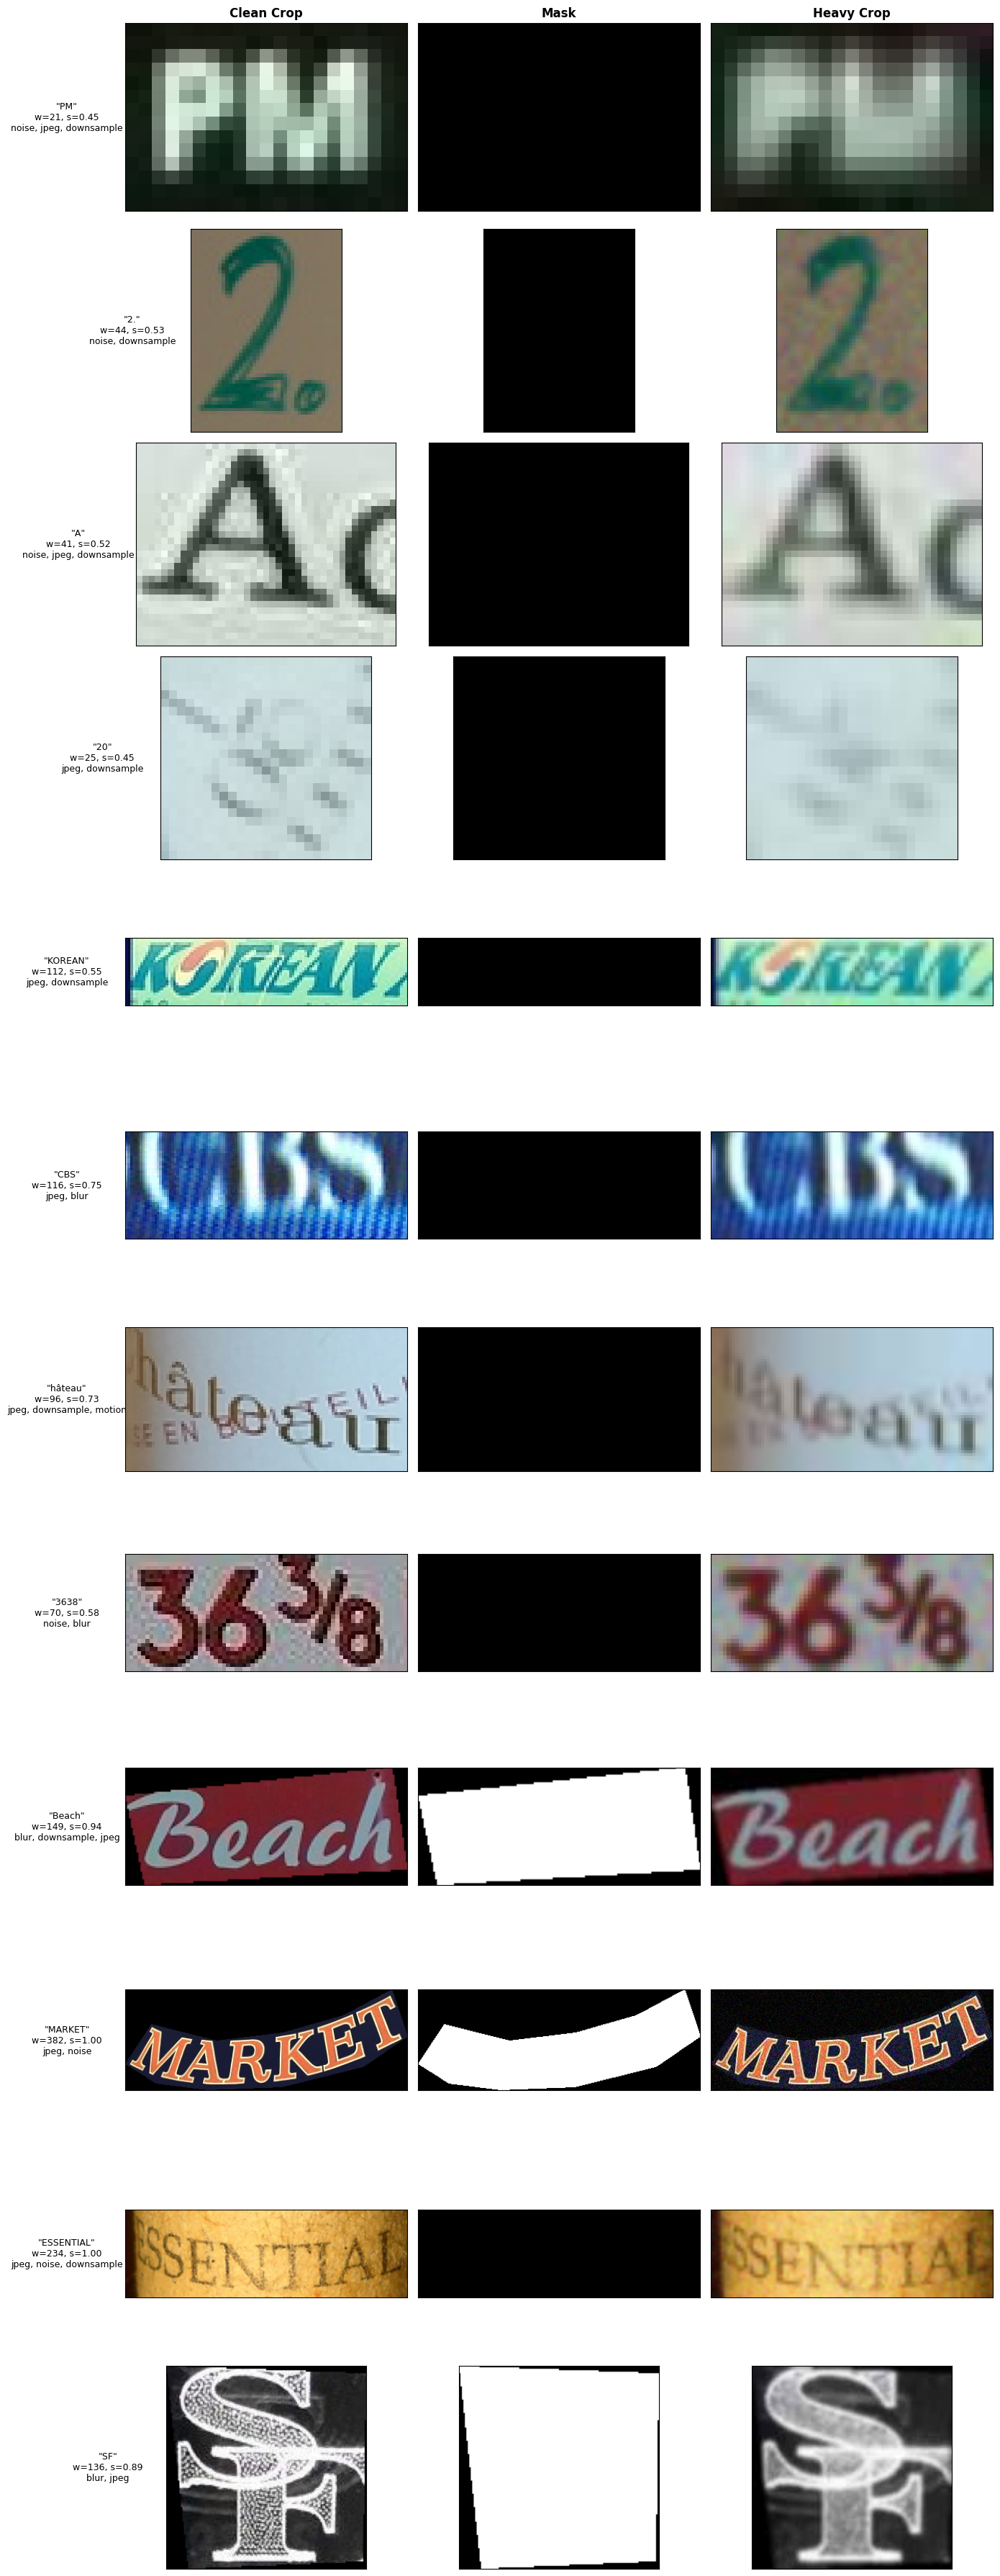

In [22]:
def summarize_benchmark_records(records):
    width_buckets = {'small': 0, 'medium': 0, 'large': 0}
    op_histogram = Counter()

    for record in records:
        clean_path = record.get('clean_crop_path', record['crop_path'])
        crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        if crop is None:
            continue
        width = crop.shape[1]
        if width < 64:
            width_buckets['small'] += 1
        elif width < 128:
            width_buckets['medium'] += 1
        else:
            width_buckets['large'] += 1
        for op in record.get('degradation_ops', []):
            op_histogram[op] += 1

    print(f'{cfg.BENCHMARK_NAME.title()} benchmark width buckets: {width_buckets}')
    print(f'{cfg.BENCHMARK_NAME.title()} benchmark op histogram: {dict(op_histogram)}')


def select_records_by_width(records, per_bucket=4, seed=42):
    rng = random.Random(seed)
    buckets = {'small': [], 'medium': [], 'large': []}

    for record in records:
        clean_path = record.get('clean_crop_path', record['crop_path'])
        crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        if crop is None:
            continue
        width = crop.shape[1]
        if width < 64:
            buckets['small'].append(record)
        elif width < 128:
            buckets['medium'].append(record)
        else:
            buckets['large'].append(record)

    selected = []
    for bucket_name in ['small', 'medium', 'large']:
        bucket = buckets[bucket_name]
        if len(bucket) <= per_bucket:
            selected.extend(bucket)
        else:
            selected.extend(rng.sample(bucket, per_bucket))
    return selected


def visualize_benchmark_crops(records, per_bucket=4, seed=42):
    selected = select_records_by_width(records, per_bucket=per_bucket, seed=seed)
    if not selected:
        raise ValueError('No records available for visualization.')

    _, axes = plt.subplots(len(selected), 3, figsize=(14, max(3 * len(selected), 8)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)

    axes[0, 0].set_title('Clean Crop', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Mask', fontsize=12, fontweight='bold')
    axes[0, 2].set_title(f'{cfg.BENCHMARK_NAME.title()} Crop', fontsize=12, fontweight='bold')

    for row, record in enumerate(selected):
        clean_path = record.get('clean_crop_path', record['crop_path'])
        clean_crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        degraded_crop = cv2.imread(record['crop_path'], cv2.IMREAD_COLOR)
        mask = cv2.imread(record['mask_path'], cv2.IMREAD_GRAYSCALE) if record.get('mask_path') else None
        if clean_crop is None or degraded_crop is None:
            continue

        clean_rgb = cv2.cvtColor(clean_crop, cv2.COLOR_BGR2RGB)
        degraded_rgb = cv2.cvtColor(degraded_crop, cv2.COLOR_BGR2RGB)
        width = clean_crop.shape[1]
        ops = ', '.join(record.get('degradation_ops', [])) or 'none'
        scale = record.get('size_scale', 1.0)

        axes[row, 0].imshow(clean_rgb)
        axes[row, 1].imshow(mask if mask is not None else np.zeros(clean_crop.shape[:2], dtype=np.uint8), cmap='gray')
        axes[row, 2].imshow(degraded_rgb)

        axes[row, 0].set_ylabel(
            f'"{record["text"]}"\nw={width}, s={scale:.2f}\n{ops}',
            fontsize=9,
            rotation=0,
            labelpad=58,
            va='center',
        )
        for col in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    plt.tight_layout()
    plt.show()


summarize_benchmark_records(final_test_records)
visualize_benchmark_crops(final_test_records, per_bucket=4, seed=cfg.SEED)

In [23]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---------------------------------------------------------------------------
# Model Architecture (matches Clovaai exactly)
# ---------------------------------------------------------------------------
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        recurrent, _ = self.rnn(x)
        return self.linear(recurrent)


class ClovaaiCRNN(nn.Module):
    """
    CRNN matching Clovaai's None-VGG-BiLSTM-CTC architecture.

    Key dimensions (for 32xW grayscale input):
      CNN: 1 -> 64 -> 128 -> 256 -> 256 -> 512(BN) -> 512(BN) -> 512(BN)
      Height: 32 -> 16 -> 8 -> 8 -> 4 -> 4 -> 2 -> 1
      Width:  W -> W/2 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4
      So W=256 -> 64 time steps for the RNN.

    Args:
        num_classes:    alphabet size including CTC blank (index 0)
        input_channel:  1 for grayscale
        output_channel: 512 (CNN final output channels)
        hidden_size:    256 (BiLSTM hidden per direction)
    """

    def __init__(self, num_classes, input_channel=1, output_channel=512,
                 hidden_size=256):
        super().__init__()
        self.num_classes = num_classes
        self.hidden_size = hidden_size
        self.output_channel = output_channel

        # -- VGG Feature Extractor (matches Clovaai exactly) --
        # Channel progression: [64, 128, 256, 512]
        oc = [output_channel // 8, output_channel // 4,
              output_channel // 2, output_channel]  # [64, 128, 256, 512]

        self.FeatureExtraction = nn.Sequential(
            nn.Conv2d(input_channel, oc[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 64x16xW/2

            nn.Conv2d(oc[0], oc[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 128x8xW/4

            nn.Conv2d(oc[1], oc[2], 3, 1, 1), nn.ReLU(True),            # -> 256x8xW/4
            nn.Conv2d(oc[2], oc[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 256x4xW/4

            nn.Conv2d(oc[2], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x4xW/4

            nn.Conv2d(oc[3], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 512x2xW/4

            nn.Conv2d(oc[3], oc[3], 2, 1, 0, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x1xW/4
        )

        # Collapse height
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        # -- BiLSTM Sequence Modeling --
        # Clovaai uses: BiLSTM(512->256->256) then BiLSTM(256->256->256)
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(output_channel, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )

        # -- CTC Prediction --
        # This layer gets replaced when loading pretrained weights
        self.Prediction = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 32, W) grayscale input
        Returns:
            log_probs: (T, B, num_classes) for CTC
        """
        # CNN: (B, 1, 32, W) -> (B, 512, 1, W/4)
        visual = self.FeatureExtraction(x)

        # Permute and pool: (B, 512, 1, W/4) -> (B, W/4, 512)
        visual = visual.permute(0, 3, 1, 2)      # (B, W/4, 512, 1)
        visual = self.AdaptiveAvgPool(visual)     # (B, W/4, 512, 1)
        visual = visual.squeeze(3)                # (B, W/4, 512)

        # BiLSTM: (B, T, 512) -> (B, T, 256)
        contextual = self.SequenceModeling(visual)

        # Prediction: (B, T, 256) -> (B, T, num_classes)
        output = self.Prediction(contextual)

        # CTC format: (T, B, num_classes)
        output = output.permute(1, 0, 2)
        log_probs = F.log_softmax(output, dim=2)
        return log_probs

In [24]:
# ---------------------------------------------------------------------------
# Weight Loading
# ---------------------------------------------------------------------------

CLOVAAI_DROPBOX_ARCHIVE_URL = (
    'https://www.dropbox.com/scl/fo/txf1v9m8p6xs8lq0yo0sc/'
    'AKjBi0yrQETefIvV_fXwXfQ?rlkey=j179442w75t7s907w6qpwhaeu&dl=1'
 )
CLOVAAI_DROPBOX_CACHE_DIR = 'clovaai_pretrained_models'


def _extract_state_dict(ckpt):
    if isinstance(ckpt, dict) and 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
        ckpt = ckpt['state_dict']
    if not isinstance(ckpt, dict):
        raise ValueError('Checkpoint does not contain a state_dict-like mapping.')
    tensor_items = {k: v for k, v in ckpt.items() if torch.is_tensor(v)}
    if not tensor_items:
        raise ValueError('Checkpoint does not contain tensor parameters.')
    return tensor_items


def _load_checkpoint_state(weights_path, device='cpu'):
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    stripped_state = {}
    for key, value in _extract_state_dict(ckpt).items():
        stripped_state[key.replace('module.', '')] = value
    return stripped_state


def _download_dropbox_archive(archive_url, archive_path):
    import shutil
    import urllib.request

    tmp_path = f'{archive_path}.part'
    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    request = urllib.request.Request(
        archive_url,
        headers={'User-Agent': 'Mozilla/5.0'},
    )

    print(f'Downloading pretrained archive from Dropbox to {archive_path}')
    with urllib.request.urlopen(request) as response, open(tmp_path, 'wb') as output_file:
        shutil.copyfileobj(response, output_file)

    os.replace(tmp_path, archive_path)


def _find_pretrained_checkpoint(root_dir, preferred_names=None, required_tokens=None):
    preferred_names = preferred_names or []
    required_tokens = [token.lower() for token in (required_tokens or [])]
    preferred_set = set(preferred_names)
    fallback_matches = []

    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if not filename.endswith('.pth'):
                continue

            full_path = os.path.join(dirpath, filename)
            if filename in preferred_set:
                return full_path

            lower_name = filename.lower()
            if all(token in lower_name for token in required_tokens):
                fallback_matches.append(full_path)

    if fallback_matches:
        return sorted(fallback_matches)[0]
    return None


def _ensure_dropbox_pretrained_file(
    save_path,
    preferred_names,
    required_tokens,
    validator,
    archive_url=CLOVAAI_DROPBOX_ARCHIVE_URL,
    cache_dir=CLOVAAI_DROPBOX_CACHE_DIR,
 ):
    import shutil
    import zipfile

    if os.path.exists(save_path) and validator(save_path):
        print(f'Pretrained weights already exist at {save_path}')
        return save_path

    if os.path.exists(save_path):
        print(f'Existing file at {save_path} is invalid. Refreshing from Dropbox archive...')
        os.remove(save_path)

    os.makedirs(cache_dir, exist_ok=True)
    extracted_dir = os.path.join(cache_dir, 'dropbox_pretrained_model')

    cached_path = None
    if os.path.isdir(extracted_dir):
        cached_path = _find_pretrained_checkpoint(
            extracted_dir,
            preferred_names=preferred_names,
            required_tokens=required_tokens,
        )
        if cached_path and validator(cached_path):
            if os.path.abspath(cached_path) != os.path.abspath(save_path):
                shutil.copy2(cached_path, save_path)
            print(f'Using cached pretrained weights from {cached_path}')
            return save_path

    archive_path = os.path.join(cache_dir, 'pretrained_model.zip')
    if not os.path.exists(archive_path) or not zipfile.is_zipfile(archive_path):
        if os.path.exists(archive_path):
            os.remove(archive_path)
        _download_dropbox_archive(archive_url, archive_path)

    if os.path.isdir(extracted_dir):
        shutil.rmtree(extracted_dir)
    os.makedirs(extracted_dir, exist_ok=True)

    print(f'Extracting pretrained archive into {extracted_dir}')
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(extracted_dir)

    cached_path = _find_pretrained_checkpoint(
        extracted_dir,
        preferred_names=preferred_names,
        required_tokens=required_tokens,
    )
    if not cached_path:
        raise FileNotFoundError(
            f'Could not find a checkpoint matching {preferred_names or required_tokens} in the Dropbox archive.'
        )

    if not validator(cached_path):
        raise ValueError(
            f'Found checkpoint at {cached_path}, but it did not match the expected model format.'
        )

    if os.path.abspath(cached_path) != os.path.abspath(save_path):
        shutil.copy2(cached_path, save_path)

    print(f'Saved pretrained weights to {save_path}')
    return save_path


def _is_clova_vgg_ctc_checkpoint(weights_path, device='cpu', verbose=True):
    try:
        state = _load_checkpoint_state(weights_path, device=device)
    except Exception as exc:
        if verbose:
            print(f'Checkpoint validation failed for {weights_path}: {exc}')
        return False

    required_keys = {
        'FeatureExtraction.ConvNet.0.weight',
        'SequenceModeling.0.rnn.weight_ih_l0',
    }
    missing = [key for key in required_keys if key not in state]
    if missing:
        if verbose:
            sample_keys = list(state.keys())[:8]
            print('Checkpoint does not look like Clova None-VGG-BiLSTM-CTC.')
            print(f'Missing required keys: {missing}')
            print(f'Sample checkpoint keys: {sample_keys}')
        return False
    return True


def download_pretrained_weights(save_path='clovaai_crnn_pretrained.pth'):
    """Resolve the None-VGG-BiLSTM-CTC checkpoint from the shared Dropbox archive."""
    return _ensure_dropbox_pretrained_file(
        save_path=save_path,
        preferred_names=['None-VGG-BiLSTM-CTC.pth'],
        required_tokens=['none', 'vgg', 'bilstm', 'ctc'],
        validator=lambda path: _is_clova_vgg_ctc_checkpoint(path, device='cpu', verbose=False),
    )


def load_clovaai_pretrained(model, weights_path, device='cuda'):
    """
    Load Clovaai VGG-BiLSTM-CTC pretrained weights into our model.

    The feature extractor and both BiLSTM layers should load almost completely.
    The Prediction layer is only loaded when the output shape matches.
    """
    print(f'Loading pretrained weights from {weights_path}')
    pretrained_state = _load_checkpoint_state(weights_path, device=device)

    own_state = model.state_dict()
    loaded_feature = 0
    loaded_sequence = 0
    loaded_prediction = 0
    skipped = 0
    mismatch_examples = []

    for name, param in pretrained_state.items():
        remapped = name.replace('FeatureExtraction.ConvNet.', 'FeatureExtraction.')

        if remapped not in own_state:
            skipped += 1
            continue

        if own_state[remapped].shape != param.shape:
            skipped += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f'{remapped}: pretrained={tuple(param.shape)}, ours={tuple(own_state[remapped].shape)}'
                )
            continue

        own_state[remapped].copy_(param)
        if remapped.startswith('FeatureExtraction.'):
            loaded_feature += 1
        elif remapped.startswith('SequenceModeling.'):
            loaded_sequence += 1
        elif remapped.startswith('Prediction.'):
            loaded_prediction += 1

    model.load_state_dict(own_state)

    print(
        f'Loaded feature params: {loaded_feature}, '
        f'sequence params: {loaded_sequence}, '
        f'prediction params: {loaded_prediction}, skipped: {skipped}'
    )
    if mismatch_examples:
        print('Sample mismatches:')
        for example in mismatch_examples:
            print(f'  - {example}')

    if loaded_feature == 0 or loaded_sequence == 0:
        raise ValueError(
            'Checkpoint load failed: expected VGG feature weights and BiLSTM weights were not loaded. '
            'The downloaded file is likely not the Clova None-VGG-BiLSTM-CTC model.'
        )

    if loaded_prediction == 0:
        print('Prediction layer was not loaded, which is expected when num_classes differs.')

    return model

In [25]:
# ---------------------------------------------------------------------------
# Build and Initialize
# ---------------------------------------------------------------------------

def build_pretrained_crnn(label_encoder, cfg, device=None):
    """
    Complete setup: build model, download weights, load, move to device.

    Returns model ready for fine-tuning.
    """
    device = device or cfg.DEVICE

    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    # Download and load pretrained weights
    weights_path = download_pretrained_weights()
    model = load_clovaai_pretrained(model, weights_path, device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,}")

    return model


# ---------------------------------------------------------------------------
# Training with Differential LR
# ---------------------------------------------------------------------------

def train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder):
    """
    Fine-tuning loop with differential learning rates.

    CNN (pretrained):   LR * 0.1
    BiLSTM (pretrained): LR * 0.5
    Prediction (new):    LR * 1.0
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    # Three param groups with different LRs
    cnn_params = [p for n, p in model.named_parameters()
                  if 'FeatureExtraction' in n]
    rnn_params = [p for n, p in model.named_parameters()
                  if 'SequenceModeling' in n]
    pred_params = [p for n, p in model.named_parameters()
                   if 'Prediction' in n]

    optimizer = optim.Adam([
        {'params': cnn_params,  'lr': cfg.LR * 0.1},   # gentle on pretrained CNN
        {'params': rnn_params,  'lr': cfg.LR * 0.5},   # moderate on pretrained RNN
        {'params': pred_params, 'lr': cfg.LR},          # full LR on new head
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]  # prediction head LR
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [26]:
# ---------------------------------------------------------------------------
# Training Utilities
# ---------------------------------------------------------------------------

class CTCLabelConverter:
    """Bridges between the label encoder and CTC loss input format."""

    @staticmethod
    def prepare_targets(targets, lengths):
        """
        CTC loss expects concatenated targets and a length tensor.
        Our collate_fn already produces this format, so this is a passthrough
        with validation.
        """
        assert targets.dim() == 1, "targets must be 1-D (concatenated)"
        assert lengths.sum().item() == targets.size(0), "length mismatch"
        return targets, lengths


class AverageMeter:
    """Running average tracker for loss and metrics."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


def greedy_decode(log_probs, label_encoder):
    """
    CTC greedy (best-path) decoding.

    Args:
        log_probs: (T, B, C) log-probabilities from the model
        label_encoder: LabelEncoder instance for index-to-char mapping

    Returns:
        list of decoded strings, one per batch element
    """
    # Argmax over classes at each time step
    _, preds = log_probs.max(2)  # (T, B)
    preds = preds.permute(1, 0)  # (B, T)

    decoded = []
    for i in range(preds.size(0)):
        raw = preds[i].cpu().tolist()
        text = label_encoder.decode(raw, remove_duplicates=True, remove_blank=True)
        decoded.append(text)
    return decoded


def compute_metrics(predictions, ground_truths):
    """
    Compute word-level accuracy and character error rate (CER).

    Args:
        predictions:    list of predicted strings
        ground_truths:  list of ground truth strings

    Returns:
        dict with 'word_acc' (exact match %) and 'cer' (character error rate %)
    """
    assert len(predictions) == len(ground_truths)

    correct = 0
    total_edit_dist = 0
    total_gt_len = 0

    for pred, gt in zip(predictions, ground_truths):
        if pred == gt:
            correct += 1
        total_edit_dist += editdistance.eval(pred, gt)
        total_gt_len += max(len(gt), 1)  # avoid division by zero

    n = max(len(predictions), 1)
    word_acc = 100.0 * correct / n
    cer = 100.0 * total_edit_dist / max(total_gt_len, 1)

    return {"word_acc": word_acc, "cer": cer}

In [27]:
# ---------------------------------------------------------------------------
# Training & Evaluation Loops
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device, label_encoder,
                    grad_clip=5.0):
    """
    Single training epoch.

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, targets, lengths = batch
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        # Forward
        log_probs = model(images)  # (T, B, C)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        # CTC loss
        loss = criterion(log_probs, targets, input_lengths, lengths)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), B)

        # Decode for metrics (no grad needed, already detached via .data)
        with torch.no_grad():
            preds = greedy_decode(log_probs, label_encoder)

        # Reconstruct ground truth strings from concatenated targets
        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, label_encoder):
    """
    Evaluation pass (validation or test).

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, targets, lengths = batch
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        log_probs = model(images)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        loss = criterion(log_probs, targets, input_lengths, lengths)
        loss_meter.update(loss.item(), B)

        preds = greedy_decode(log_probs, label_encoder)

        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics

In [28]:
def train(model, train_loader, val_loader, cfg, label_encoder):
    """
    Full training loop with LR scheduling, gradient clipping, and
    best-model checkpointing based on validation word accuracy.

    Args:
        model:          CRNN instance (already on device)
        train_loader:   training DataLoader
        val_loader:     validation DataLoader
        cfg:            Config object
        label_encoder:  LabelEncoder instance

    Returns:
        history: dict of lists keyed by metric name
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [],
        "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        # -- Train --
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        # -- Validate --
        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        # -- LR step --
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        # -- Log --
        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        # -- Checkpoint best model --
        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
                "cfg": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [29]:
# ---------------------------------------------------------------------------
# Inference Helpers
# ---------------------------------------------------------------------------

def load_model(checkpoint_path, label_encoder, cfg, device=None):
    """
    Load a trained ClovaaiCRNN checkpoint for inference.

    Args:
        checkpoint_path:  path to .pth file saved by training
        label_encoder:    LabelEncoder matching the training charset
        cfg:              Config object
        device:           target device (defaults to cfg.DEVICE)

    Returns:
        model on the specified device, in eval mode
    """
    device = device or cfg.DEVICE
    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
          f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)")
    return model


def predict_batch(model, images, label_encoder, device=None):
    """
    Run inference on a batch of preprocessed image tensors.

    Args:
        model:          ClovaaiCRNN in eval mode
        images:         (B, 1, H, W) tensor
        label_encoder:  LabelEncoder instance
        device:         target device

    Returns:
        list of predicted strings
    """
    device = device or next(model.parameters()).device
    images = images.to(device)
    with torch.no_grad():
        log_probs = model(images)
    return greedy_decode(log_probs, label_encoder)

In [30]:
print(f"Train records: {len(final_train_records)}")
print(f"Train batches: {len(train_loader)}")

Train records: 89255
Train batches: 1372


In [31]:
# widths = []
# for img_path, text, polygon in final_train_records[:2000]:
#     img = cv2.imread(img_path)
#     if img is None:
#         continue
#     crop = crop_polygon_region(img, polygon, target_h=32)
#     if crop is not None:
#         widths.append(crop.shape[1])

# print(f"Width stats: min={min(widths)}, max={max(widths)}, "
#       f"mean={np.mean(widths):.0f}, median={np.median(widths):.0f}, "
#       f"95th={np.percentile(widths, 95):.0f}")

In [32]:
# ---------------------------------------------------------------------------
# Training with optional freezing for ClovaaiCRNN
# ---------------------------------------------------------------------------

def set_module_trainable(module, trainable):
    for param in module.parameters():
        param.requires_grad = trainable


def train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder):
    """
    Training loop with feature-extractor freeze/unfreeze schedule.

    Strategy:
      - Epochs 1 to freeze_cnn: feature extractor frozen, sequence/head train
      - Remaining epochs: full fine-tuning with lower LR for the feature extractor
    """
    device = cfg.DEVICE
    freeze_epochs = getattr(cfg, 'FREEZE_CNN_EPOCHS', 0)

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    feat_params = [p for n, p in model.named_parameters() if n.startswith('FeatureExtraction')]
    seq_params = [p for n, p in model.named_parameters() if n.startswith('SequenceModeling')]
    pred_params = [p for n, p in model.named_parameters() if n.startswith('Prediction')]

    optimizer = optim.Adam([
        {'params': feat_params, 'lr': cfg.LR * 0.1},
        {'params': seq_params, 'lr': cfg.LR * 0.5},
        {'params': pred_params, 'lr': cfg.LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    if freeze_epochs > 0:
        set_module_trainable(model.FeatureExtraction, False)

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        if freeze_epochs > 0 and epoch == freeze_epochs + 1:
            set_module_trainable(model.FeatureExtraction, True)
            print(f"       ** Unfreezing feature extractor at epoch {epoch}")

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [33]:
required_globals = [
    'Config', 'cfg', 'label_encoder', 'TotalTextDataset', 'collate_fn',
    'final_train_records', 'final_val_records', 'final_test_records',
    'prepare_crnn_records', 'build_pretrained_crnn',
    'train_with_pretrained', 'evaluate', 'ClovaaiCRNN',
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    print(f'MISSING: {missing}')
else:
    print('All baseline globals present.')
    print(f'final_train_records: {len(final_train_records)} crops')
    print(f'final_val_records:   {len(final_val_records)} crops')
    print(f'final_test_records:  {len(final_test_records)} crops')

All baseline globals present.
final_train_records: 89255 crops
final_val_records:   10798 crops
final_test_records:  10364 crops


In [34]:
# if __name__ == "__main__":
#     # Add these to your Config:
#     # FREEZE_CNN_EPOCHS = 3    # freeze CNN for first 3 epochs
#     # LR = 1e-4               # keep the lower LR that was working

#     model = ResNetCRNN(
#         num_classes=label_encoder.num_classes,
#         rnn_hidden=cfg.RNN_HIDDEN_SIZE,
#         rnn_layers=cfg.RNN_NUM_LAYERS,
#         rnn_dropout=cfg.RNN_DROPOUT,
#         pretrained=True,
#         freeze_cnn=getattr(cfg, 'FREEZE_CNN_EPOCHS', 0),
#     ).to(cfg.DEVICE)

#     total = sum(p.numel() for p in model.parameters())
#     trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"Total parameters:     {total:,}")
#     print(f"Trainable parameters: {trainable:,}")
#     print(f"CNN params: {model.cnn_params:,}, RNN params: {model.rnn_params:,}")

#     history = train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder)
#     # plot_training_history(history)

#     # Final test
#     criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
#     test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
#     print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
#           f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

VERIFY IF TPG ALREADY EXISTS ON DRIVE

In [35]:
import os
tpg_path = '/content/drive/MyDrive/tpgsr_project/crnn_tpg_clean_v2_best.pth'
print(f'TPG v2 exists: {os.path.exists(tpg_path)}')
print(f'Size: {os.path.getsize(tpg_path)/1e6:.1f} MB' if os.path.exists(tpg_path) else 'MISSING')

TPG v2 exists: False
MISSING


In [36]:
import sys
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

In [37]:
import sys
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from tpgsr.tpg_config import TPGCRNNConfig
from tpgsr.train_tpg import train_tpg_crnn

tpg_cfg = TPGCRNNConfig()
tpg_cfg.SAVE_PATH = '/content/weights/crnn_tpg_clean_v2_best.pth'

tpg_v2_model, tpg_v2_test_metrics = train_tpg_crnn(tpg_cfg)

Phase 0 — Training TPG-CRNN on CLEAN crops
Epochs:       12
Freeze CNN:   1 epoch(s)
Batch size:   64
Base LR:      0.0002
LR step:      4 (gamma=0.5)
Weight decay: 0.0001
Augment:      ON
Save path:    /content/weights/crnn_tpg_clean_v2_best.pth
Device:       cuda
----------------------------------------------------------------------
TPG-CRNN clean train: kept 87804 / 89255 records after CRNN normalization (skipped 1451)
TPG-CRNN clean val: kept 10621 / 10798 records after CRNN normalization (skipped 177)
TPG-CRNN clean test: kept 10030 / 10364 records after CRNN normalization (skipped 334)
Train augmentation: ON
TPG train batches: 1372
TPG val batches:   166
TPG test batches:  157
Pretrained weights already exist at clovaai_crnn_pretrained.pth
Loading pretrained weights from clovaai_crnn_pretrained.pth
Loaded feature params: 21, sequence params: 20, prediction params: 2, skipped: 1
Total parameters:     8,452,133
Trainable parameters: 8,452,133
Epoch |  TrLoss |  TrAcc |  TrCER |  Va

In [38]:
import os
p = '/content/weights/crnn_tpg_clean_v2_best.pth'
print(f'Exists: {os.path.exists(p)}, Size: {os.path.getsize(p)/1e6:.1f} MB')

Exists: True, Size: 101.5 MB


In [39]:
import sys

# Clear any cached tpgsr modules from previous imports
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from tpgsr.train_tpgsr import train_tpgsr
tpgsr_model, tpgsr_history = train_tpgsr()

Phase 1 — Training TPGSR (TSRN + frozen CRNN-TPG)
LR -> HR:           16x64 -> 32x128
Input channels:     4 (RGB + polygon mask)
Iterations:         2
Loss weights:       L1=1.0 MSE=1.0 CTC=0.1
Epochs / batch:     30 / 64
LR schedule:        0.0001 -> 1e-06 (cosine)
Width filter:       [40, 160]
TPG checkpoint:     /content/weights/crnn_tpg_clean_v2_best.pth
Save path:          /content/weights/tsrn_heavy_best.pth
Device:             cuda
------------------------------------------------------------------------------
Normalizing text (charset filter + length filter)...
TPGSR train: kept 87804 / 89255 records after CRNN normalization (skipped 1451)
TPGSR val: kept 10621 / 10798 records after CRNN normalization (skipped 177)
Filtering records by width...
  Train: 36320 / 87804 records in width range
  Val:   4254 / 10621 records in width range
Train batches: 567  Val batches: 67
Loading frozen TPG...
TPG loaded from /content/weights/crnn_tpg_clean_v2_best.pth
  checkpoint epoch: 12, val_a

In [40]:
import sys
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from tpgsr.build_sr_cache import build_sr_cache
sr_train, sr_val, sr_test = build_sr_cache()

Phase 2 — Caching SR outputs for all splits
TSRN:               /content/weights/tsrn_heavy_best.pth
TPG:                /content/weights/crnn_tpg_clean_v2_best.pth
SR cache root:      /content/data/sr_cache/heavy
Width range:        [40, 160]
Batch size:         128
Device:             cuda
----------------------------------------------------------------------
Loading TSRN checkpoint: /content/weights/tsrn_heavy_best.pth
TPG loaded from /content/weights/crnn_tpg_clean_v2_best.pth
  checkpoint epoch: 12, val_acc: 60.4%, val_cer: 27.0%
  TSRN checkpoint epoch 21, val_tpg_acc=18.9%, val_psnr=21.71 dB
  [train] 128 / 89255  (935 rec/s, ETA 95s)
  [train] 2688 / 89255  (1033 rec/s, ETA 84s)
  [train] 5248 / 89255  (1046 rec/s, ETA 80s)
  [train] 7808 / 89255  (1043 rec/s, ETA 78s)
  [train] 10368 / 89255  (1049 rec/s, ETA 75s)
  [train] 12928 / 89255  (1059 rec/s, ETA 72s)
  [train] 15488 / 89255  (1054 rec/s, ETA 70s)
  [train] 18048 / 89255  (1055 rec/s, ETA 68s)
  [train] 20608 / 89255 

In [41]:
import os
import pickle

sr_root = '/content/data/sr_cache/heavy'

# Basic size and manifest check
for split in ['train', 'val', 'test']:
    manifest_path = f'{sr_root}/{split}/manifest.pkl'
    with open(manifest_path, 'rb') as f:
        records = pickle.load(f)
    sr_applied = sum(1 for r in records if r.get('sr_applied'))
    passthrough = len(records) - sr_applied
    print(f'{split}: {len(records)} records  |  SR: {sr_applied}  |  passthrough: {passthrough}')

# Check sample grids exist
for split in ['train', 'val', 'test']:
    sample_path = f'{sr_root}/samples_{split}.png'
    if os.path.exists(sample_path):
        print(f'  {sample_path}  {os.path.getsize(sample_path)/1024:.0f} KB')

train: 89255 records  |  SR: 36463  |  passthrough: 52792
val: 10798 records  |  SR: 4277  |  passthrough: 6521
test: 10364 records  |  SR: 4345  |  passthrough: 6019
  /content/data/sr_cache/heavy/samples_train.png  424 KB
  /content/data/sr_cache/heavy/samples_val.png  416 KB
  /content/data/sr_cache/heavy/samples_test.png  460 KB


In [42]:
# cfg.SAVE_PATH = '/content/drive/MyDrive/tpgsr_project/crnn_totaltext_heavy_best.pth'
# print(f'Will save to: {cfg.SAVE_PATH}')
# print(f'Epochs: {cfg.NUM_EPOCHS}')
# print(f'Batch size: {cfg.BATCH_SIZE}')

COMMENTED OUT TO AVOID REUSE

In [43]:
# if __name__ == "__main__":
#     # Optional CRNN fine-tuning overrides:
#     # cfg.BATCH_SIZE = 48        # lower if GPU memory is tight
#     # cfg.LR = 2e-4
#     cfg.SAVE_PATH = '/content/weights/crnn_totaltext_heavy_best.pth'
#     cfg.NUM_EPOCHS = 12
#     # cfg.LR_STEP = 6
#     # cfg.LR_GAMMA = 0.7
#     # cfg.FREEZE_CNN_EPOCHS = 1
#     # cfg.WEIGHT_DECAY = 5e-5

#     model = build_pretrained_crnn(label_encoder, cfg)

#     history = train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder)
#     # plot_training_history(history)

#     # Final test
#     criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
#     test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
#     print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
#           f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

In [44]:
import sys
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from tpgsr.finetune_crnn import finetune_crnn_on_sr
ft_model, ft_history = finetune_crnn_on_sr()

Phase 3 — Fine-tuning CRNN on SR cache
Baseline:   /content/weights/crnn_totaltext_heavy_best.pth
SR cache:   /content/data/sr_cache/heavy
Save path:  /content/drive/MyDrive/tpgsr_project/crnn_tpgsr_finetuned_best.pth
Epochs:     6
LR:         0.0002
Device:     cuda
------------------------------------------------------------------------------
SR cache loaded: train=89255 (36463 SR / 52792 passthrough), val=10798, test=10364
SR-CRNN train: kept 87804 / 89255 records after CRNN normalization (skipped 1451)
SR-CRNN val: kept 10621 / 10798 records after CRNN normalization (skipped 177)
Train batches: 1372  Val batches: 166
Loaded baseline CRNN: epoch 9, val_acc=34.4%, val_cer=50.2%
Feature extractor FROZEN for first 1 epoch(s)
 Ep |  TrLoss |  VaLoss  VaAcc  VaCER |        LR |  Time
---------------------------------------------------------
  1 |  1.8503 |  1.9782  32.3%  52.0% | 2.00e-05 |   41s
       ** Saved best model (val_acc=32.3%)
   ** Unfreezing feature extractor at epoch 2
  2

In [45]:
import sys
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from tpgsr.evaluate_tpgsr import evaluate_tpgsr_pipeline
metrics = evaluate_tpgsr_pipeline(baseline_heavy_acc=37.5)

Phase 4 — Evaluating CRNN-TPGSR pipeline on SR test cache
Fine-tuned checkpoint: /content/drive/MyDrive/tpgsr_project/crnn_tpgsr_finetuned_best.pth
SR test cache:         /content/data/sr_cache/heavy/test
------------------------------------------------------------------------------
SR test records: 10364  (4345 SR / 6019 passthrough)
SR-CRNN test: kept 10030 / 10364 records after CRNN normalization (skipped 334)
Loaded fine-tuned CRNN: epoch 6, val_acc=33.8%, val_cer=50.6%
FINAL CRNN-TPGSR RESULT on heavy test set
  Word accuracy: 36.8%
  CER:           46.4%
  Loss:          1.8933
------------------------------------------------------------------------------
  Baseline (heavy-trained CRNN): 37.5%
  TPGSR (fine-tuned on SR):      36.8%
  Delta:                         -0.7 points
  Verdict:  NEGATIVE — pipeline needs debugging


In [47]:
import torch
import torch.nn as nn
import pickle
from torch.utils.data import DataLoader
import sys

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Force fresh imports
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

from tpgsr.sr_crnn_dataset import SRCRNNDataset
from tpgsr.finetune_config import FinetuneConfig

# Load test records
with open('/content/data/sr_cache/heavy/test/manifest.pkl', 'rb') as f:
    sr_test = pickle.load(f)

# Split records by SR vs passthrough
sr_records = [r for r in sr_test if r.get('sr_applied')]
pass_records = [r for r in sr_test if not r.get('sr_applied')]

print(f'SR records:         {len(sr_records)}')
print(f'Passthrough records: {len(pass_records)}')

ft_cfg = FinetuneConfig()

# Normalize (same as Phase 4)
sr_norm = prepare_crnn_records(sr_records, 'SR subset')
pass_norm = prepare_crnn_records(pass_records, 'Passthrough subset')

# Load fine-tuned model
model = ClovaaiCRNN(
    num_classes=label_encoder.num_classes,
    input_channel=cfg.IMG_CHANNELS,
    output_channel=cfg.CNN_OUT_CHANNELS,
    hidden_size=cfg.RNN_HIDDEN_SIZE,
).to(cfg.DEVICE)
ckpt = torch.load(ft_cfg.SAVE_PATH, map_location=cfg.DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])

# Also load baseline for passthrough reference
baseline_model = ClovaaiCRNN(
    num_classes=label_encoder.num_classes,
    input_channel=cfg.IMG_CHANNELS,
    output_channel=cfg.CNN_OUT_CHANNELS,
    hidden_size=cfg.RNN_HIDDEN_SIZE,
).to(cfg.DEVICE)
baseline_ckpt = torch.load(
    '/content/weights/crnn_totaltext_heavy_best.pth',
    map_location=cfg.DEVICE, weights_only=False,
)
baseline_model.load_state_dict(baseline_ckpt['model_state_dict'])

criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction='mean', zero_infinity=True)

# Evaluate fine-tuned on each subset
sr_ds = SRCRNNDataset(sr_norm, label_encoder, cfg, augment=False)
sr_loader = DataLoader(sr_ds, batch_size=64, shuffle=False, num_workers=4, collate_fn=collate_fn)
pass_ds = SRCRNNDataset(pass_norm, label_encoder, cfg, augment=False)
pass_loader = DataLoader(pass_ds, batch_size=64, shuffle=False, num_workers=4, collate_fn=collate_fn)

print('\n--- Fine-tuned CRNN ---')
sr_metrics_ft = evaluate(model, sr_loader, criterion, cfg.DEVICE, label_encoder)
pass_metrics_ft = evaluate(model, pass_loader, criterion, cfg.DEVICE, label_encoder)
print(f'  SR subset:          {sr_metrics_ft["word_acc"]:.1f}% (on SR outputs)')
print(f'  Passthrough subset: {pass_metrics_ft["word_acc"]:.1f}% (on degraded)')

print('\n--- Baseline CRNN on same inputs ---')
sr_metrics_base = evaluate(baseline_model, sr_loader, criterion, cfg.DEVICE, label_encoder)
pass_metrics_base = evaluate(baseline_model, pass_loader, criterion, cfg.DEVICE, label_encoder)
print(f'  SR subset:          {sr_metrics_base["word_acc"]:.1f}% (on SR outputs)')
print(f'  Passthrough subset: {pass_metrics_base["word_acc"]:.1f}% (on degraded)')

print('\n--- Delta (fine-tuned - baseline) ---')
print(f'  SR subset:          {sr_metrics_ft["word_acc"] - sr_metrics_base["word_acc"]:+.1f}')
print(f'  Passthrough subset: {pass_metrics_ft["word_acc"] - pass_metrics_base["word_acc"]:+.1f}')

SR records:         4345
Passthrough records: 6019
SR subset: kept 4304 / 4345 records after CRNN normalization (skipped 41)
Passthrough subset: kept 5726 / 6019 records after CRNN normalization (skipped 293)

--- Fine-tuned CRNN ---
  SR subset:          43.3% (on SR outputs)
  Passthrough subset: 31.9% (on degraded)

--- Baseline CRNN on same inputs ---
  SR subset:          38.5% (on SR outputs)
  Passthrough subset: 31.6% (on degraded)

--- Delta (fine-tuned - baseline) ---
  SR subset:          +4.7
  Passthrough subset: +0.4
